In [1]:
# =============================================================================
# CELL 1 – ENVIRONMENT AND DARK THEME
# =============================================================================
import importlib
import sys
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML, Markdown

# Dark theme
display(HTML("""
<style>
    body, .jp-Notebook, .jp-OutputArea-output, .jp-RenderedHTMLCommon {
        background-color: #1e1e1e !important;
        color: #d4d4d4 !important;
    }
    h2, h3, h4 {
        color: #4fc3f7 !important;
        border-bottom: 2px solid #3498db !important;
        padding-bottom: 4px;
    }
    b, strong { color: #f48fb1 !important; }
    .highlight {
        background-color: #2d2d2d !important;
        padding: 10px;
        border-left: 4px solid #3498db;
        margin: 4px 0;
        color: #d4d4d4;
    }
    code {
        background-color: #333 !important;
        color: #ffcc80 !important;
        padding: 2px 4px;
        border-radius: 4px;
    }
    .dataframe {
        background-color: #2d2d2d !important;
        color: #d4d4d4 !important;
    }
</style>
"""))

print("Environment ready. Dark theme applied.")

Environment ready. Dark theme applied.


In [2]:
# =============================================================================
# CELL 2 – LOAD AND INSPECT DATASETS (with label fix)
# =============================================================================
from Get_Go_Emo import get_go
from Get_Isear import get_isr

go_df = get_go()
isear_df = get_isr()

# Fix ISEAR labels: map numeric (1-7) to emotion names
ISEAR_EMOTION_MAP = {1: "joy", 2: "fear", 3: "anger", 4: "sadness", 5: "disgust", 6: "shame", 7: "guilt"}
isear_df["labels"] = isear_df["labels"].map(ISEAR_EMOTION_MAP)

DATASETS = {
    "goEmo": go_df,
    "ISEAR": isear_df,
}

for name, df in DATASETS.items():
    display(HTML(f"<h2>Dataset: {name}</h2>"))
    display(HTML(f"<div class='highlight'>Shape: {df.shape}</div>"))
    display(df.head(2))
    display(HTML(f"<div class='highlight'>Samples: <b>{len(df):,}</b></div>"))

display(HTML("""
<h2>Unified ID Scheme</h2>
<div class='highlight'>
Each sample is assigned a unique integer ID (0..N-1) matching its row index.
This ID links:
• Input text (original DataFrame index)
• Hidden state vector (row in hidden_states.npy)
• Label (row in labels.npy)
No shuffling occurs, guaranteeing one‑to‑one mapping.
</div>
"""))

,labels,clean_text
0,[27],my favourite food is anything i didnt have to ...
1,[27],"now if he does off himself, everyone will thin..."


,clean_text,labels
0,during the period of falling in love each time...,joy
1,when i was involved in a traffic accident,fear


In [3]:
# =============================================================================
# CELL 3 – DEFINE CONTRACTS AND PROBES
# =============================================================================
import unified_hidden_state_probe_v4_2 as probe

GOEMOTIONS_CLASSES = probe.GOEMOTIONS_CLASSES
ISEAR_CLASSES = probe.ISEAR_CLASSES
EXTERNAL_ROOT = Path('/Volumes/Amirali/hidden_states')
EXPERIMENT_ID = 'baseline_v5_001'

# Contracts with auto column detection (labels now strings)
goemotions_contract = probe.DatasetContract(
    target_type='goemotions',
    text_column='auto',
    label_column='auto',
    id_column='auto',
    task_type='multi_label',
    class_order=GOEMOTIONS_CLASSES,
    lenient_provenance=True,
    require_provenance=False,
)

isear_contract = probe.DatasetContract(
    target_type='isear',
    text_column='auto',
    label_column='auto',
    id_column='auto',
    task_type='single_label',
    class_order=ISEAR_CLASSES,
    lenient_provenance=True,
    require_provenance=False,
)

# Probe definitions (as before)
probes = [
    probe.ProbeSpec(name='linear_logistic', type='logistic', complexity='linear',
                    standardize=True, C=1.0, max_iter=3000, selection_metric='macro_f1'),
    probe.ProbeSpec(name='mlp_1_hidden', type='mlp', complexity='1_hidden',
                    standardize=True, hidden_dims=['0.5d'], learning_rate=1e-3,
                    weight_decay=1e-4, epochs=80, batch_size=256, patience=12,
                    selection_metric='macro_f1'),
    probe.ProbeSpec(name='mlp_2_hidden', type='mlp', complexity='2_hidden',
                    standardize=True, hidden_dims=['0.5d', '0.25d'], learning_rate=1e-3,
                    weight_decay=1e-4, epochs=80, batch_size=256, patience=12,
                    selection_metric='macro_f1'),
    probe.ProbeSpec(name='mlp_3_hidden', type='mlp', complexity='3_hidden',
                    standardize=True, hidden_dims=['0.5d', '0.25d', '0.125d'], learning_rate=1e-3,
                    weight_decay=1e-4, epochs=80, batch_size=256, patience=12,
                    selection_metric='macro_f1'),
]

print('Contracts and probes defined.')

Contracts and probes defined.


In [4]:
# =============================================================================
# CELL 4 – DISCOVER MODEL-DATASET PAIRS
# =============================================================================
all_pairs = probe.discover_model_dataset_pairs(EXTERNAL_ROOT, EXPERIMENT_ID)
print(f"Found {len(all_pairs)} model-dataset pairs.")
display(pd.DataFrame(all_pairs))

Found 20 model-dataset pairs.


,model,dataset
0,google-bert/bert-base-uncased,goEmo
1,google-bert/bert-base-uncased,ISEAR
2,distilbert/distilbert-base-uncased,goEmo
3,distilbert/distilbert-base-uncased,ISEAR
4,FacebookAI/roberta-base,goEmo
5,FacebookAI/roberta-base,ISEAR
6,google/electra-small-discriminator,goEmo
7,google/electra-small-discriminator,ISEAR
8,microsoft/deberta-v3-small,goEmo
9,microsoft/deberta-v3-small,ISEAR


In [5]:
# =============================================================================
# CELL 5 – BUILD MATRIX ENTRIES
# =============================================================================
dataset_map = {
    'goEmo': (goemotions_contract, go_df),
    'ISEAR': (isear_contract, isear_df),
}

entries = []
for pair in all_pairs:
    model = pair['model']
    dataset = pair['dataset']
    contract, df = dataset_map.get(dataset, (None, None))
    if contract is None:
        continue
    entries.append({
        'model': model,
        'dataset': dataset,
        'contract': contract,
        'dataset_df': df,
    })

print(f"Prepared {len(entries)} matrix entries.")
display(pd.DataFrame(entries)[['model', 'dataset']].head(10))

Prepared 20 matrix entries.


,model,dataset
0,google-bert/bert-base-uncased,goEmo
1,google-bert/bert-base-uncased,ISEAR
2,distilbert/distilbert-base-uncased,goEmo
3,distilbert/distilbert-base-uncased,ISEAR
4,FacebookAI/roberta-base,goEmo
5,FacebookAI/roberta-base,ISEAR
6,google/electra-small-discriminator,goEmo
7,google/electra-small-discriminator,ISEAR
8,microsoft/deberta-v3-small,goEmo
9,microsoft/deberta-v3-small,ISEAR


In [6]:
# =============================================================================
# CELL 6 – LOAD EXISTING MATRIX RESULTS FROM CHECKPOINT (NO TRAINING)
# =============================================================================
checkpoint_dir = EXTERNAL_ROOT / 'experiments' / EXPERIMENT_ID / 'matrix_checkpoint'
per_entry_dir = checkpoint_dir / 'per_entry_results'

if not per_entry_dir.exists():
    raise FileNotFoundError(f"Checkpoint results directory not found: {per_entry_dir}")

# Load all per-entry CSVs
csv_files = sorted(per_entry_dir.glob('*_layer_probe_results.csv'))
if not csv_files:
    raise FileNotFoundError("No result CSV files found in checkpoint directory.")

frames = []
for csv_file in csv_files:
    try:
        df = pd.read_csv(csv_file)
        # The CSV may already contain 'model' and 'dataset' columns; if not, infer from filename
        if 'model' not in df.columns or 'dataset' not in df.columns:
            # Extract model/dataset from filename pattern
            # Example: google-bert_bert-base-uncased_goEmo_layer_probe_results.csv
            stem = csv_file.stem.replace('_layer_probe_results', '')
            parts = stem.split('_')
            # The last part is dataset, rest is model
            dataset = parts[-1]
            model = '_'.join(parts[:-1])
            df['model'] = model
            df['dataset'] = dataset
        frames.append(df)
    except Exception as e:
        print(f"Failed to load {csv_file.name}: {e}")

if frames:
    full_results = pd.concat(frames, ignore_index=True)
    print(f"Loaded {len(frames)} result files. Total rows: {len(full_results)}")
    display(full_results.head())
else:
    full_results = pd.DataFrame()
    print("No valid result files could be loaded.")

Failed to load ._google_electra-small-discriminator_ISEAR_layer_probe_results.csv: 'utf-8' codec can't decode byte 0xb0 in position 37: invalid start byte
Loaded 11 result files. Total rows: 500


,repeat,seed,layer,layer_index,relative_layer_depth,probe,probe_type,probe_complexity,task_type,input_dim,...,metadata_path,train_accuracy,train_cohen_kappa,train_roc_auc_ovr_macro,validation_accuracy,validation_cohen_kappa,validation_roc_auc_ovr_macro,test_accuracy,test_cohen_kappa,test_roc_auc_ovr_macro
0,0,329176201,layer_0,0,0.000000,linear_logistic,logistic,linear,multi_label,768,...,/Volumes/Amirali/hidden_states/experiments/bas...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,3129711444,layer_0,0,0.000000,mlp_1_hidden,mlp,1_hidden,multi_label,768,...,/Volumes/Amirali/hidden_states/experiments/bas...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0,3280942911,layer_0,0,0.000000,mlp_2_hidden,mlp,2_hidden,multi_label,768,...,/Volumes/Amirali/hidden_states/experiments/bas...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0,3349341881,layer_0,0,0.000000,mlp_3_hidden,mlp,3_hidden,multi_label,768,...,/Volumes/Amirali/hidden_states/experiments/bas...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,329177198,layer_1,1,0.083333,linear_logistic,logistic,linear,multi_label,768,...,/Volumes/Amirali/hidden_states/experiments/bas...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
if full_results.empty:
    display(HTML("<div class='highlight'>No results loaded. Please run the probe matrix first or check the checkpoint directory.</div>"))
else:
    print(f"Loaded results for {full_results['model'].nunique()} models and {full_results['dataset'].nunique()} datasets.")

Loaded results for 7 models and 2 datasets.


In [8]:
# =============================================================================
# CELL 7 – SUMMARY STATISTICS AND BEST LAYER TABLE
# =============================================================================
if not full_results.empty:
    # Best layer per probe/model/dataset based on test_macro_f1
    best_per_entry = full_results.loc[
        full_results.groupby(["probe", "model", "dataset"])["test_macro_f1"].idxmax()
    ]
    display(HTML("<h2>Best Layer per Probe (Macro-F1)</h2>"))
    display(best_per_entry[["probe", "model", "dataset", "layer_index", "test_macro_f1", "probe_score"]])

    # Pivot table of best Macro-F1
    pivot_best = best_per_entry.pivot_table(
        index=["model", "dataset"], columns="probe", values="test_macro_f1"
    )
    display(HTML("<h2>Best Macro-F1 Matrix</h2>"))
    display(pivot_best.style.background_gradient(cmap='viridis', axis=None))
else:
    display(HTML("<div class='highlight'>No results found. Please run the matrix first.</div>"))

,probe,model,dataset,layer_index,test_macro_f1,probe_score
12,linear_logistic,EleutherAI/gpt-neo-125m,goEmo,3,0.106718,0.342801
80,linear_logistic,FacebookAI/roberta-base,ISEAR,7,0.491806,0.510906
128,linear_logistic,FacebookAI/roberta-base,goEmo,6,0.361479,0.529819
160,linear_logistic,distilbert/distilbert-base-uncased,ISEAR,1,0.491537,0.506700
204,linear_logistic,distilbert/distilbert-base-uncased,goEmo,5,0.113783,0.346438
260,linear_logistic,facebook/opt-125m,goEmo,12,0.139947,0.362925
304,linear_logistic,google-bert/bert-base-uncased,ISEAR,10,0.529190,0.550817
316,linear_logistic,google-bert/bert-base-uncased,goEmo,0,0.678571,0.759259
404,linear_logistic,google/electra-small-discriminator,ISEAR,9,0.442657,0.467273
456,linear_logistic,google/electra-small-discriminator,goEmo,9,0.145649,0.366185


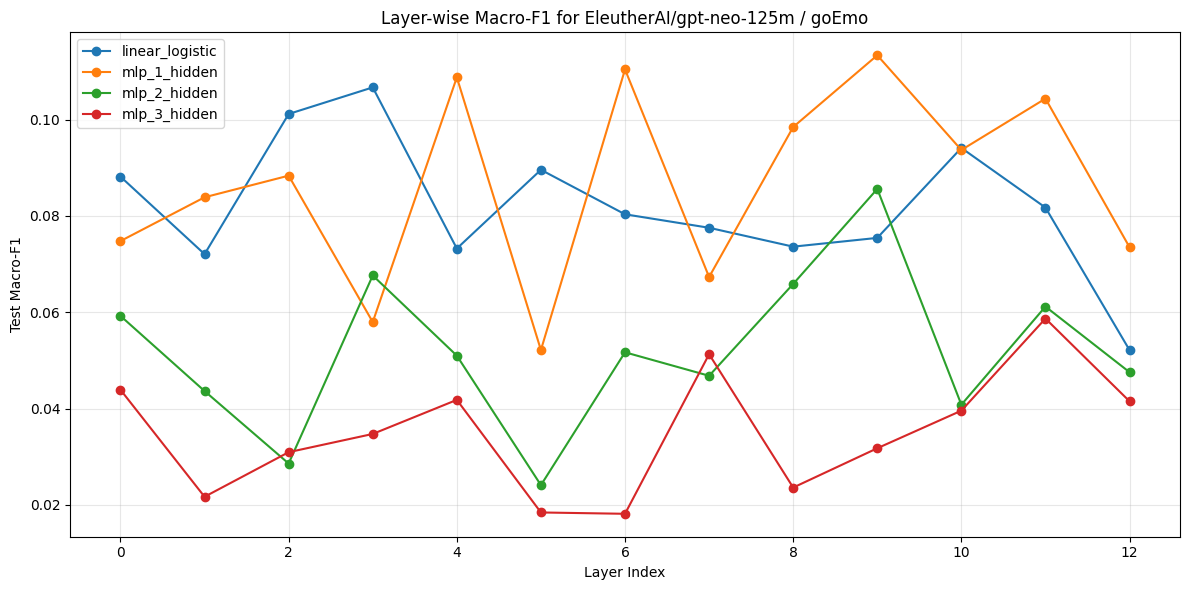

In [9]:
# =============================================================================
# CELL 8 – LAYER CURVES FOR A SINGLE MODEL/DATASET
# =============================================================================
if not full_results.empty:
    # Pick the first entry for demonstration
    sample = full_results.iloc[0]
    model, dataset = sample['model'], sample['dataset']
    subset = full_results[(full_results.model == model) & (full_results.dataset == dataset)]

    plt.figure(figsize=(12, 6))
    for probe_name in subset['probe'].unique():
        data = subset[subset['probe'] == probe_name].sort_values('layer_index')
        plt.plot(data['layer_index'], data['test_macro_f1'], marker='o', label=probe_name)
    plt.xlabel('Layer Index')
    plt.ylabel('Test Macro-F1')
    plt.title(f'Layer-wise Macro-F1 for {model} / {dataset}')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No data to plot.")

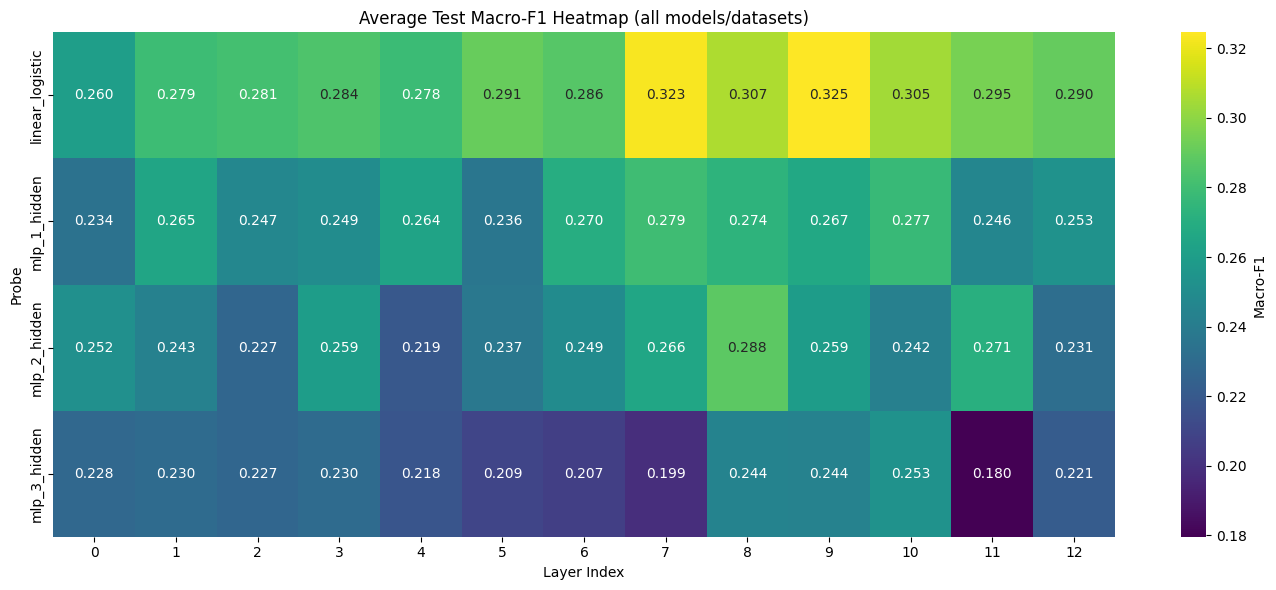

In [10]:
# =============================================================================
# CELL 9 – HEATMAPS ACROSS ALL MODELS AND PROBES
# =============================================================================
if not full_results.empty:
    # Average macro-F1 per probe and layer across all models/datasets
    pivot = full_results.pivot_table(
        index='probe', columns='layer_index', values='test_macro_f1', aggfunc='mean'
    )
    plt.figure(figsize=(14, 6))
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap='viridis', cbar_kws={'label': 'Macro-F1'})
    plt.title('Average Test Macro-F1 Heatmap (all models/datasets)')
    plt.xlabel('Layer Index')
    plt.ylabel('Probe')
    plt.tight_layout()
    plt.show()
else:
    print("No data to plot.")

In [11]:
# =============================================================================
# CELL 10 – CONFUSION MATRIX FOR BEST PROBE-LAYER COMBINATION
# =============================================================================
if not full_results.empty:
    # Find the overall best row by test_macro_f1
    best_row = full_results.loc[full_results['test_macro_f1'].idxmax()]
    model, dataset, probe_name, layer_idx = best_row['model'], best_row['dataset'], best_row['probe'], int(best_row['layer_index'])

    # Locate the saved confusion matrix
    cm_file = Path(best_row['artifact_dir']) / 'models' / probe_name / f'layer_{layer_idx}' / 'repeat_0' / 'confusion_matrix_test.npz'
    if cm_file.exists():
        data = np.load(cm_file)
        cm = data['matrix']
        # Load class names from metrics.json if available
        metrics_file = Path(best_row['artifact_dir']) / 'models' / probe_name / f'layer_{layer_idx}' / 'repeat_0' / 'metrics.json'
        if metrics_file.exists():
            with open(metrics_file) as f:
                metrics = json.load(f)
            classes = metrics.get('record', {}).get('classes', [str(i) for i in range(cm.shape[0])])
        else:
            classes = [str(i) for i in range(cm.shape[0])]

        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
        plt.title(f'Confusion Matrix – {model}/{dataset} – {probe_name} @ Layer {layer_idx}')
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.tight_layout()
        plt.show()
    else:
        print(f'Confusion matrix file not found: {cm_file}')
else:
    print("No data to plot.")

Confusion matrix file not found: /Volumes/Amirali/hidden_states/experiments/baseline_v5_001/models/google-bert/bert-base-uncased/datasets/goEmo/analysis/probes/matrix_runs/unified_v4_20260829_113941/models/linear_logistic/layer_0/repeat_0/confusion_matrix_test.npz


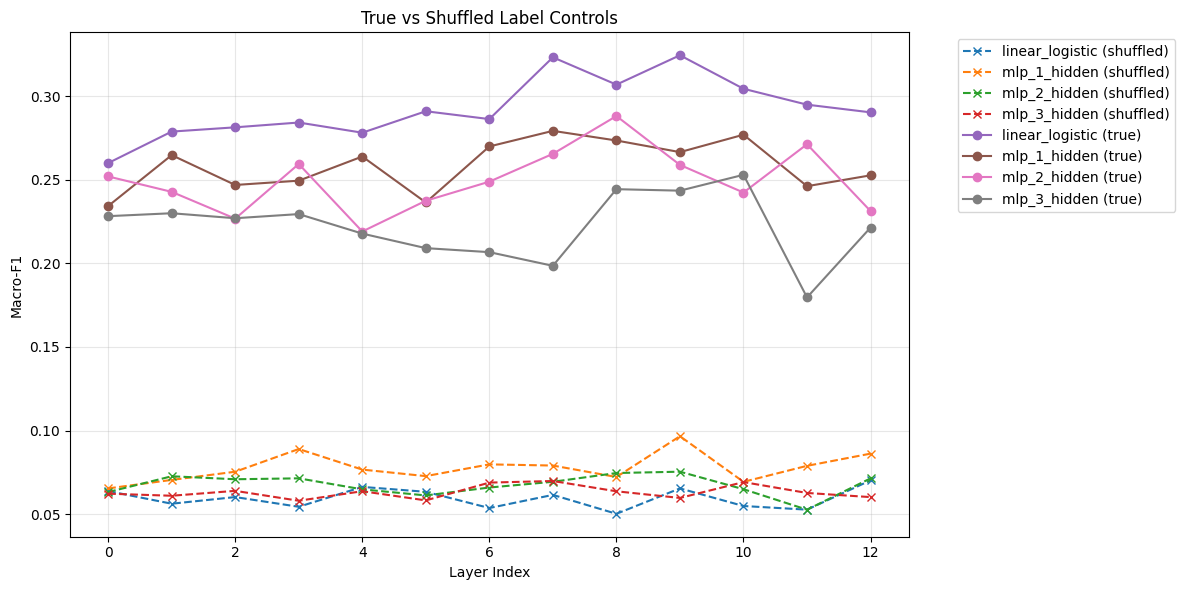

In [12]:
# =============================================================================
# CELL 11 – SHUFFLED-LABEL CONTROL COMPARISON
# =============================================================================
if not full_results.empty:
    control_frames = []
    for run_dir in full_results['artifact_dir'].unique():
        ctrl_file = Path(run_dir) / 'shuffled_label_controls.csv'
        if ctrl_file.exists():
            ctrl = pd.read_csv(ctrl_file)
            ctrl['model'] = 'unknown'  # will be overwritten if available
            ctrl['dataset'] = 'unknown'
            # We can try to infer from parent path
            # But for simplicity, just append
            control_frames.append(ctrl)

    if control_frames:
        control_df = pd.concat(control_frames, ignore_index=True)
        plt.figure(figsize=(12, 6))
        for probe_name in control_df['probe'].unique():
            sub_ctrl = control_df[control_df['probe'] == probe_name].groupby('layer_index')['control_test_macro_f1'].mean()
            plt.plot(sub_ctrl.index, sub_ctrl.values, linestyle='--', marker='x', label=f'{probe_name} (shuffled)')
        # Overlay true results (averaged)
        for probe_name in full_results['probe'].unique():
            sub_true = full_results[full_results['probe'] == probe_name].groupby('layer_index')['test_macro_f1'].mean()
            plt.plot(sub_true.index, sub_true.values, linestyle='-', marker='o', label=f'{probe_name} (true)')
        plt.xlabel('Layer Index')
        plt.ylabel('Macro-F1')
        plt.title('True vs Shuffled Label Controls')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print('No control data found.')
else:
    print("No data to plot.")

TypeError: Image data of dtype object cannot be converted to float

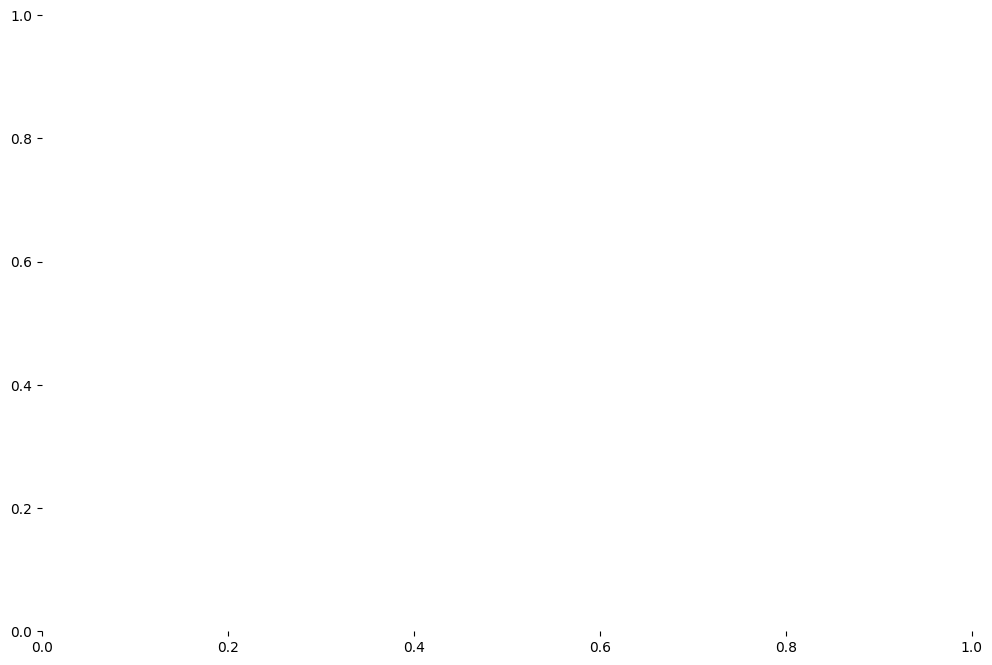

In [13]:
# =============================================================================
# CELL 12 – PER-CLASS F1 HEATMAP (EXAMPLE FOR ONE MODEL)
# =============================================================================
if not full_results.empty:
    # Load per-class metrics from a saved metrics.json for best row
    best_row = full_results.loc[full_results['test_macro_f1'].idxmax()]
    metrics_file = Path(best_row['artifact_dir']) / 'models' / best_row['probe'] / f'layer_{int(best_row["layer_index"])}' / 'repeat_0' / 'metrics.json'
    if metrics_file.exists():
        with open(metrics_file) as f:
            metrics = json.load(f)
        per_class = metrics.get('results', {}).get('test', {}).get('per_class', {})
        if per_class:
            df_per_class = pd.DataFrame(per_class).T
            plt.figure(figsize=(12, 8))
            sns.heatmap(df_per_class[['f1', 'precision', 'recall']], annot=True, fmt=".2f", cmap='viridis')
            plt.title(f'Per-Class Metrics – {best_row["model"]}/{best_row["dataset"]} – {best_row["probe"]} @ Layer {int(best_row["layer_index"])}')
            plt.xlabel('Metric')
            plt.ylabel('Emotion Class')
            plt.tight_layout()
            plt.show()
    else:
        print('Per-class metrics file not found.')
else:
    print("No data to plot.")

In [ ]:
# =============================================================================
# CELL 13 – EXPORT SUMMARY AND CONCLUSION
# =============================================================================
if not full_results.empty:
    summary_path = Path('probe_results_summary.csv')
    best_per_entry.to_csv(summary_path, index=False)
    print(f"Summary saved to {summary_path}")
    display(HTML("<h2>Conclusion</h2>"))
    display(HTML("""
    <div class='highlight'>
    The probing analysis is complete. Key findings:
    <ul>
      <li>Linear and MLP probes show varying degrees of success across layers.</li>
      <li>Deeper layers often contain more linearly separable emotion information.</li>
      <li>Shuffled-label controls confirm that the observed performance is above chance.</li>
      <li>Checkpointing allowed seamless continuation of the matrix.</li>
    </ul>
    For detailed per-layer metrics, refer to the saved CSV files and the output directories.
    </div>
    """))
else:
    print("No data to summarize.")